In [7]:
import torch

from utils.checkpoints import load_ae_from_path, load_cspn_from_path, load_from_wandb
from utils.visualisation import (
    plot_latent_space,
    show,
)


In [8]:
ae_path = load_from_wandb("autoencoder_flowers102")
ae = load_ae_from_path(ae_path, device=torch.device("mps"))

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_flowers102_beta0.5.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_flowers102:latest


In [9]:
cspn_psi_path = load_from_wandb("cspn_flowers102_psinet")
cspn_psi = load_cspn_from_path(cspn_psi_path, device=torch.device("mps"))

Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/cspn_flowers102_psinet.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/cspn_flowers102_psinet:latest


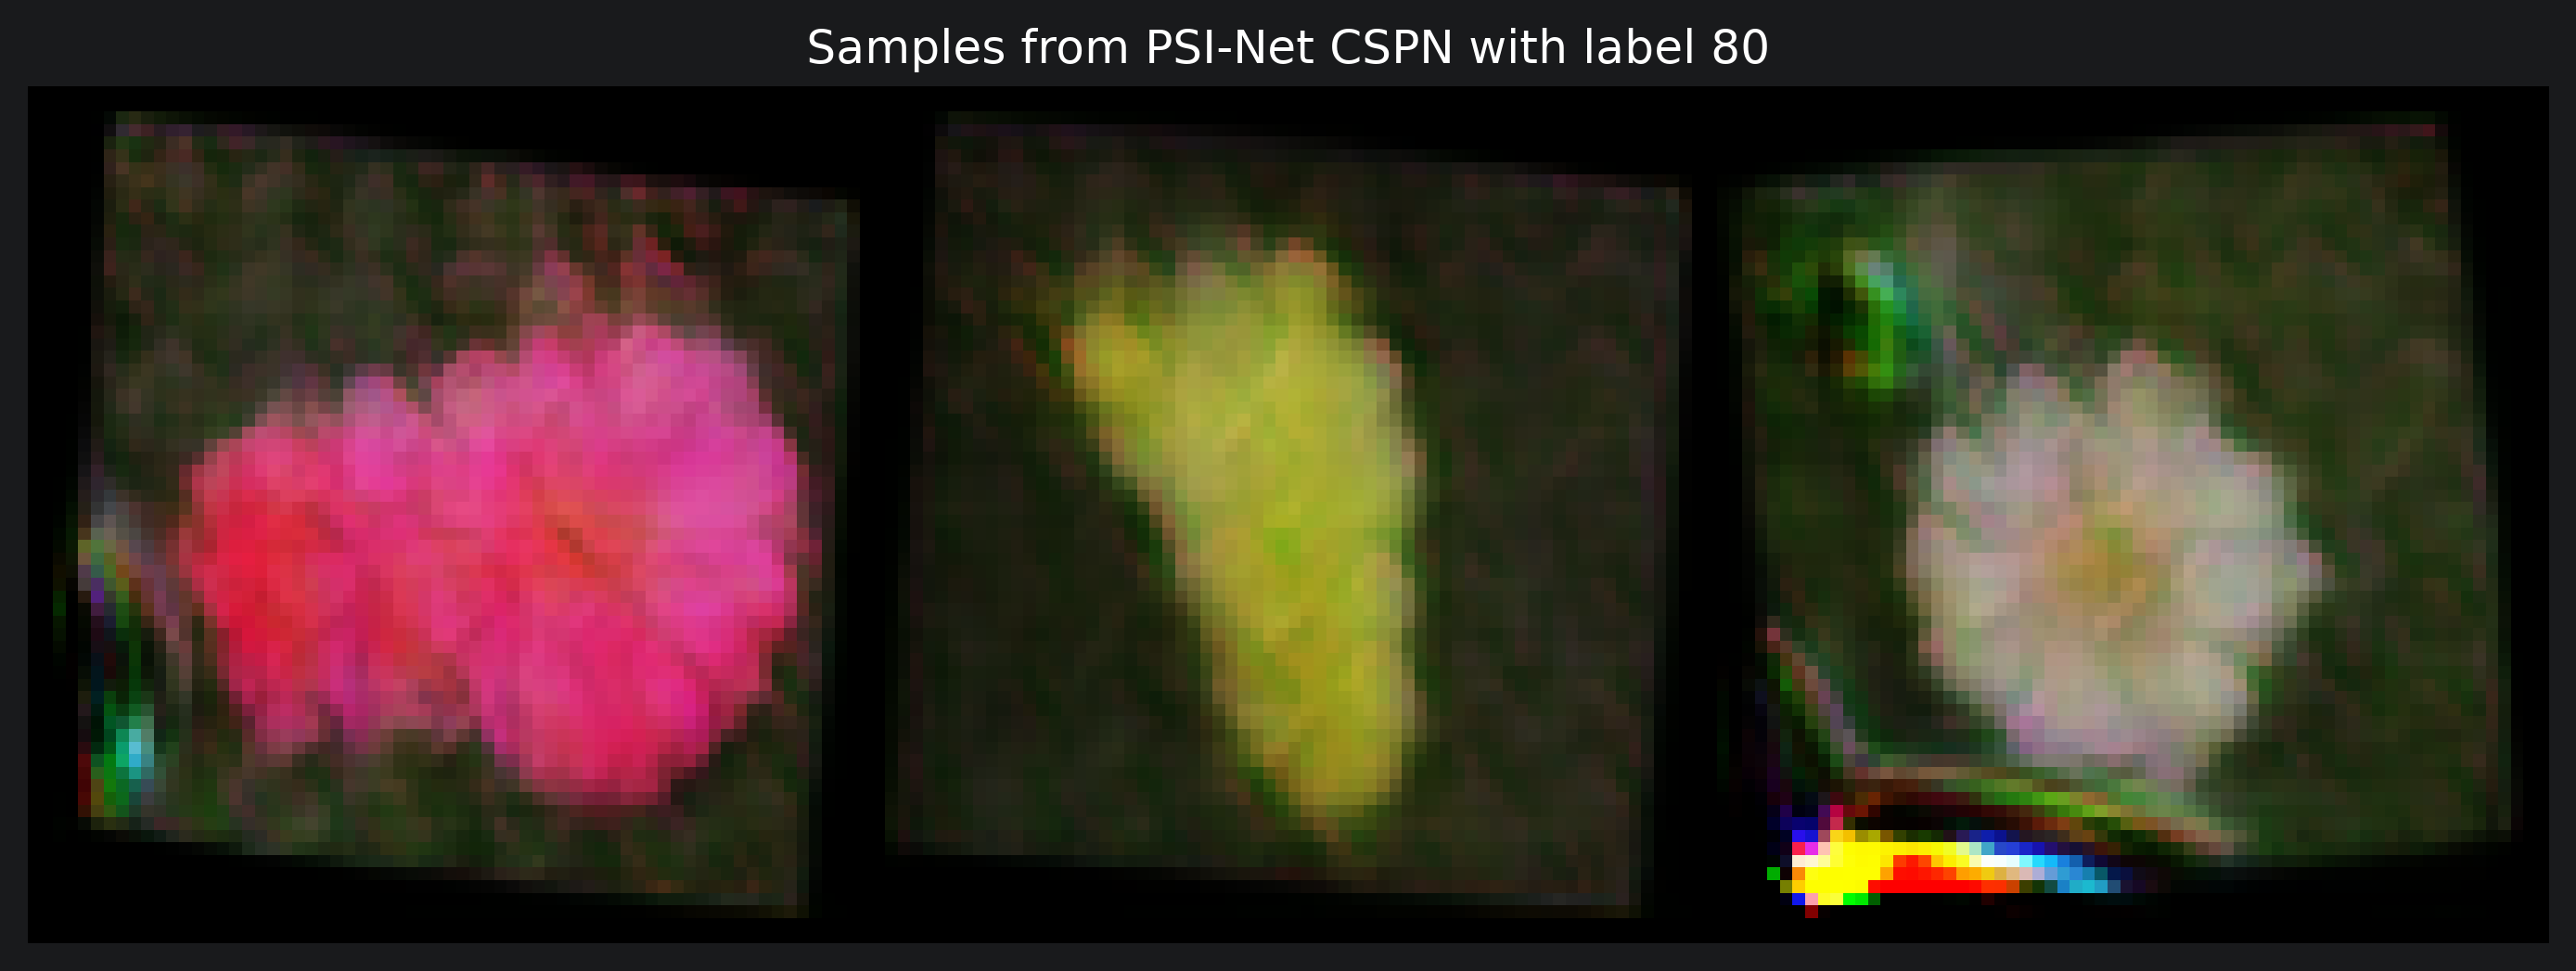

In [30]:
label = 80
sample_labels = torch.tensor([label] * 3)

with torch.no_grad():
    samples_psi = cspn_psi.sample(sample_labels)
    sampled_images_psi = ae.decode(samples_psi)

show(sampled_images_psi, f"Samples from PSI-Net CSPN with label {label}")

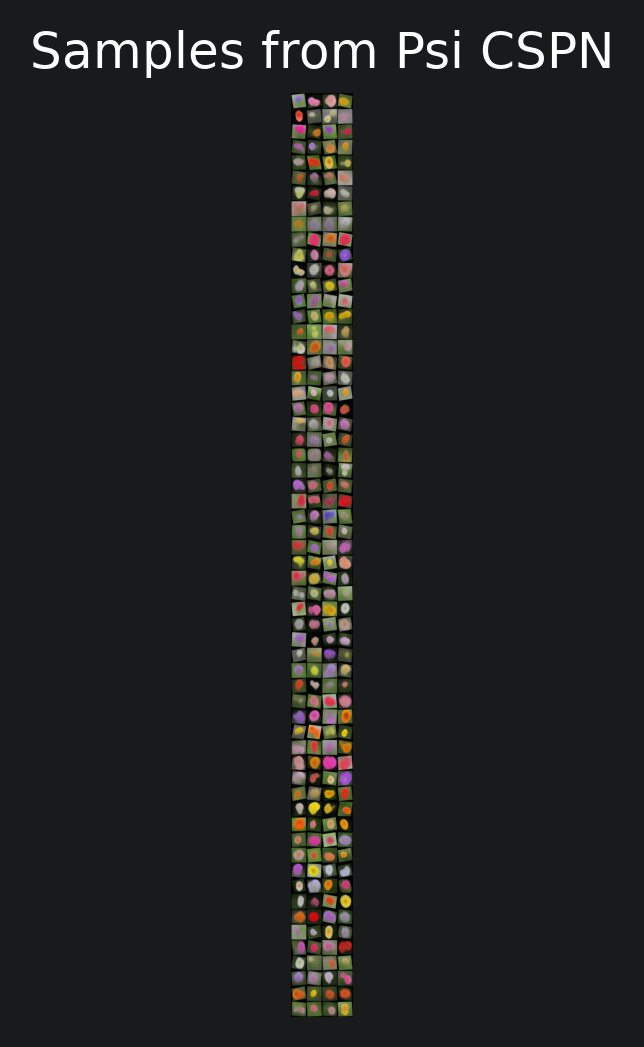

In [24]:
all_labels = torch.arange(0, 60).repeat_interleave(4)

with torch.no_grad():
    samples_psi = cspn_psi.sample(all_labels)
    sampled_images_psi = ae.decode(samples_psi)

show(sampled_images_psi, "Samples from Psi CSPN", width=4)

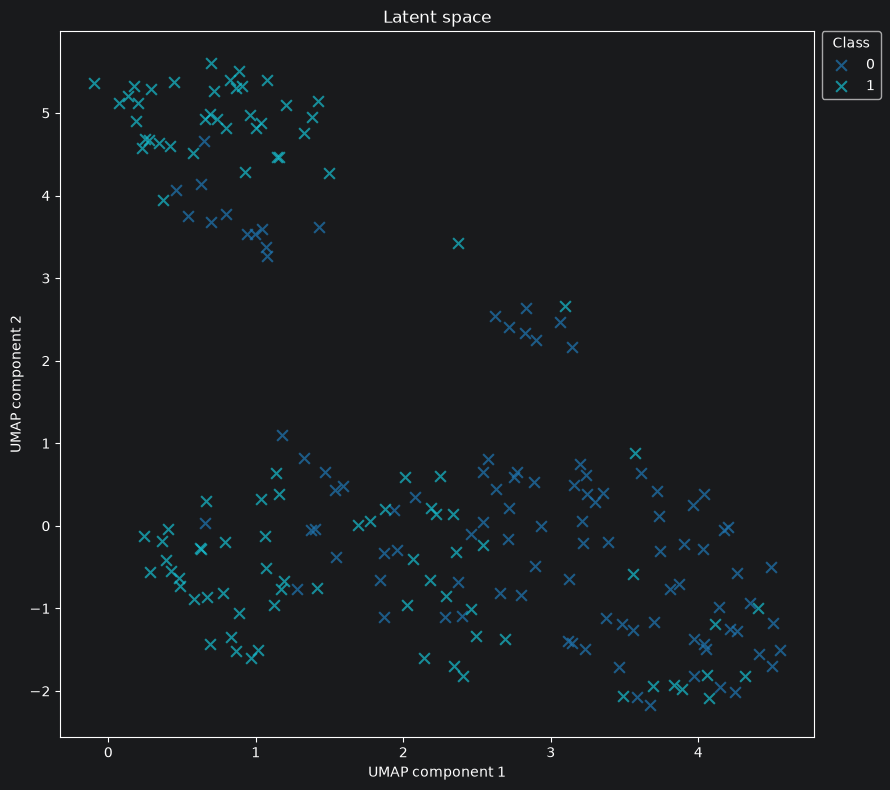

In [12]:
sample_multi_labels = torch.arange(0, 2).repeat_interleave(100)
with torch.no_grad():
    samples_psi = cspn_psi.sample(sample_multi_labels)

plot_latent_space(samples_psi, sample_multi_labels)